# Computing Tempered Energy 

We aim to implement a parallel tempering scheme for annealed MCMC as per Du et al.'s [2024 paper](https://arxiv.org/pdf/2302.11552) on compositional generation with energy-based diffusion. In order to implement parallel tempering into the sampling regime of annealed MCMC, we aim to evaluate the difference between true tempered energy and our approximations.

Training follows standard DDPM noise-matching objective


Sampling follows annealed MCMC

Input:
- Transition kernels $k_t(· | ·)$
- Initial distribution $p_T(·)$
- Number of steps $N$

Sampling steps:
- Initialize $x_T \sim p_T(·)$
- for $t = T, T-1, ... ,  0$ do
	- for $i = 1, ... ,  N$ do
		- $x_t \sim k_t(· | x_t)$
	- end for
	- $x_{t-1} = x_t$
- end for

For our transition kernel, we choose ULA algorithm
$$q(x_t\mid x_{t-1}) = N(x_{t-1} + \frac{\sigma_L^2}{2} \nabla_x f(x_{t-1}), \sigma_L^2 I)$$
We choose step size $\beta_t$
$$x_{t+1} = x_t - \beta_t \nabla_x p_t(x) + \sqrt{2} \beta_t z$$
where
$$\nabla \text{model output} = \nabla_x p_t(x) = \frac{\epsilon_{\theta}(x_t, t)}{\sqrt{1-\bar{\alpha}_t}}$$
See appendix b.2 of reduce reuse recycle and section 2.2

### Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np 
import torch

from src.config import DEVICE, DATASETS, CKPT_DIR, TRAINING, N_DIFFUSION_STEPS
from src.sample import sampling
from src.eval import plot_samples_grid, samples_tuning
from src.train import train_model
from src.schedule import betas, alphas, alpha_bars, ts_desc

device = DEVICE

# Training hyperparams
n_steps = TRAINING["n_steps"]
batch_size = TRAINING["batch_size"]
lr = TRAINING["lr"]
n_diffusion_steps = N_DIFFUSION_STEPS
ckpt_dir = CKPT_DIR

### Train

3.611574411392212


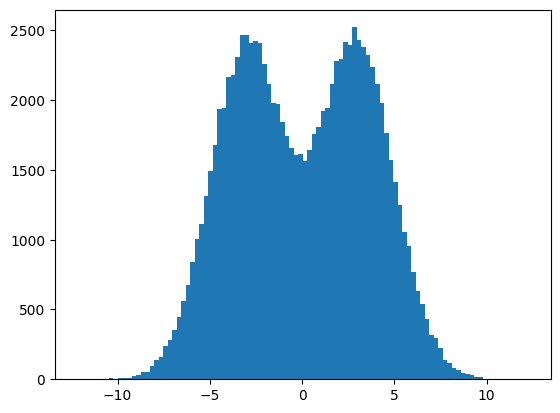

In [2]:
barrier_1 = torch.normal(-3, 2, (50000,))
barrier_2 = torch.normal(3, 2, (50000,))
peak = torch.normal(0, 0.5, (50000,))
combined = torch.cat((barrier_1, barrier_2), dim=0)
print(combined.std().item())
_ = plt.hist(combined, bins = 100)

In [3]:
# dataset_names = ["single_overlapping", "barrier_overlapping", "composed_overlapping"]

# for name in dataset_names:
#     dataset_config = DATASETS[name]
#     model = train_model(dataset_config)

### Sample

Note that function `plot_samples_grid` will take in a list of methods and dataset names and plot them in a grid. Function `samples_tuning` will take in a single method (ULA or MALA) and dataset name, as well as a list `step_scales_list` and `n_langevin_steps_list` and output a grid of samples for each hyperparameter. 

In [ ]:
methods = ["MALA"]

dataset_names = ["composed"]

for k in [4.0]:

	_ = plot_samples_grid(dataset_names, methods, k=k, sigma=None, x_limit = 10)